In [162]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import src

In [164]:
load_profile = src.generate_daily_load_profile() #this is the profile of a random industry

In [165]:
def create_grid_profile(dt, wind_penetration=0.25):
    load_profile = src.generate_daily_load_profile(dt=dt) 
    wind_speed = src.simulate_ou_process(x0=10, theta=0.0002, mu=11.2, sigma=0.007, T= 24*60*60, dt=dt)
    wind_power_generation = src.wind_power_generation_vec(wind_speed)
    wind_power_generation = wind_penetration * (wind_power_generation / wind_power_generation.mean())

    df = pd.DataFrame(wind_power_generation)
    df.columns = ['P_wind']

    df.index = load_profile.index
    profile = pd.concat([load_profile, df], axis=1).drop(columns='aux')

    # initialize columns as zero just as a placeholder
   
    profile["P_generator"] = 0
    profile["P_battery"] = 0
    profile["frequency"] = 0

    return profile


In [166]:
profile = create_grid_profile(dt=0.1, wind_penetration=0.25)

In [167]:
profile

,P_load,P_wind,P_generator,P_battery,frequency
0.0,0.498086,0.181283,0,0,0
0.1,0.500338,0.181358,0,0,0
0.2,0.494943,0.181585,0,0,0
0.3,0.508028,0.181561,0,0,0
0.4,0.503127,0.181564,0,0,0
...,...,...,...,...,...
86399.6,0.497664,0.272224,0,0,0
86399.7,0.498448,0.272149,0,0,0
86399.8,0.499128,0.272246,0,0,0
86399.9,0.499679,0.272511,0,0,0


In [168]:
# create a for loop for the wind and load power, from that, set how much power goes to the battery system 
# to see if it should be charging or discharging based off the needs of our grid
# 1. set generator to start with (1 - wind_penetration) * load value
# 2. for each iteration, calculates the power capacity of our battery system to decide if we can charge it more and/or discharge it
# 3. for small P_load - P_wind - P_generator - P_battery values, only change the charge or discharge of battery
# 4. if deviation is large, we need to actually change the generator P_gen
      

In [169]:
def apply_droop_control(p_ref, f_current, f_nom, r_droop, deadzone=0.02):
    """
    Adjusts the power reference based on frequency deviation, 
    with a deadzone to ignore small fluctuations.
    
    deadzone: frequency deviation in Hz (e.g., 0.02 Hz)
    """
    delta_f = f_current - f_nom
    
    # Check if we are inside the deadzone
    if abs(delta_f) <= deadzone:
        return p_ref
    
    adjustment_f = delta_f - (np.sign(delta_f) * deadzone)
    
    p_droop_adjustment = -(1.0 / r_droop) * (adjustment_f / f_nom)
    
    return p_ref + p_droop_adjustment

In [170]:
apply_droop_control(0.5, 49.96, 50, 0.05, 0.02)

np.float64(0.5079999999999997)

In [171]:
for index in (profile.index):
    if index == 0:
        print("sim")
        profile.loc[index, "P_generator"] = profile.loc[index, "P_load"] - profile.loc[index, "P_wind"]
        profile.loc[index, "frequency"] = 50

        freq0 = profile.loc[index, "frequency"]
        P_gen0 = profile.loc[index, "P_generator"]


    else:
        P_load = profile.loc[index, "P_load"]
        P_wind = profile.loc[index, "P_wind"]

        profile.loc[index, "frequency"] = src.solve_swing_equation(freq0, P_gen0, P_load - P_wind)
        freq0 = profile.loc[index, "frequency"] # this will be the old frequency for the next iteration, also the current one for the droop calculation

        profile.loc[index, "P_generator"] = apply_droop_control(P_gen0, freq0, f_nom = 50, r_droop=0.05, deadzone = 0.02)

        P_gen0 = profile.loc[index, "P_generator"]


sim


C:\Users\Vinicius\AppData\Local\Temp\ipykernel_3712\2906184315.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.3168035947982251' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  profile.loc[index, "P_generator"] = profile.loc[index, "P_load"] - profile.loc[index, "P_wind"]
C:\Users\Vinicius\AppData\Local\Temp\ipykernel_3712\2906184315.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '49.99996891953975' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  profile.loc[index, "frequency"] = src.solve_swing_equation(freq0, P_gen0, P_load - P_wind)


In [172]:
# src.solve_swing_equation(f_prev, p_gen, p_load, h, d, dt, fnom)

In [173]:
profile

,P_load,P_wind,P_generator,P_battery,frequency
0.0,0.498086,0.181283,0.316804,0,50.000000
0.1,0.500338,0.181358,0.316804,0,49.999969
0.2,0.494943,0.181585,0.316804,0,50.000019
0.3,0.508028,0.181561,0.316804,0,49.999880
0.4,0.503127,0.181564,0.316804,0,49.999815
...,...,...,...,...,...
86399.6,0.497664,0.272224,0.236129,0,50.005547
86399.7,0.498448,0.272149,0.236129,0,50.005568
86399.8,0.499128,0.272246,0.236129,0,50.005581
86399.9,0.499679,0.272511,0.236129,0,50.005589


<Axes: >

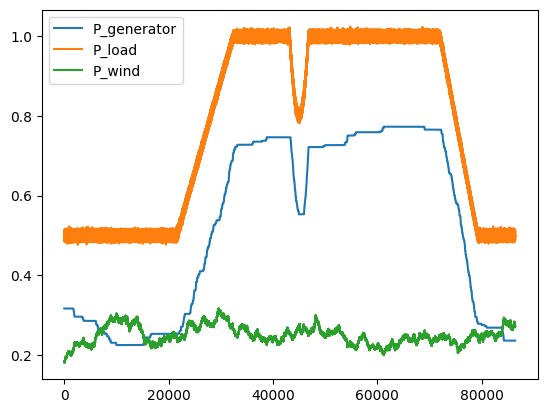

In [175]:
profile[["P_generator", "P_load", "P_wind"]].plot()

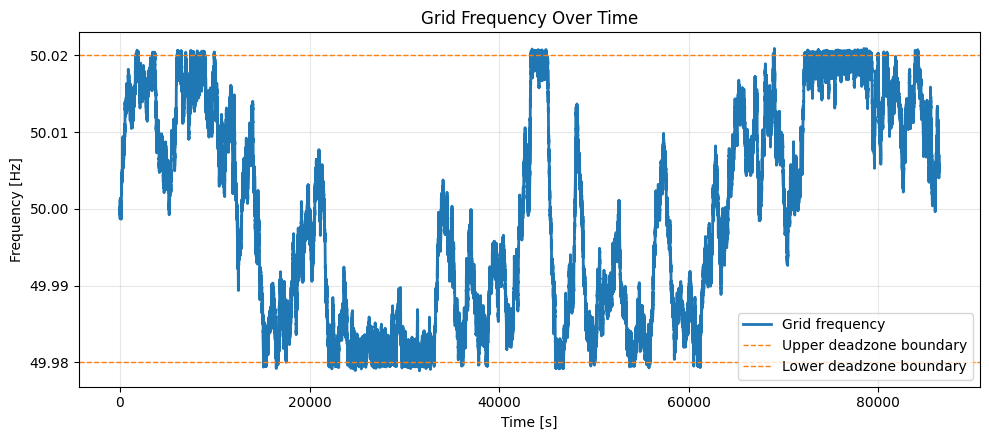

In [176]:
plt.figure(figsize=(10, 4.5))

plt.plot(
    profile.index,
    profile["frequency"],
    linewidth=2,
    color="tab:blue",
    label="Grid frequency"
)

plt.axhline(
    50.02,
    color="tab:orange",
    linestyle="--",
    linewidth=1,
    label="Upper deadzone boundary"
)

plt.axhline(
    49.98,
    color="tab:orange",
    linestyle="--",
    linewidth=1,
    label="Lower deadzone boundary"
)

plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.title("Grid Frequency Over Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()